<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/day3_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

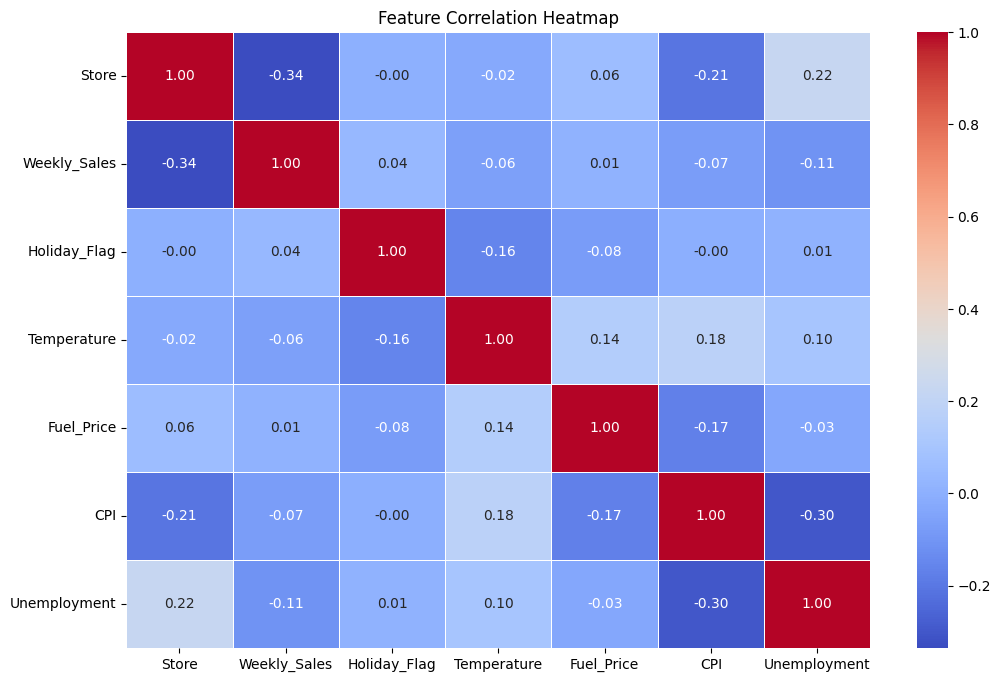

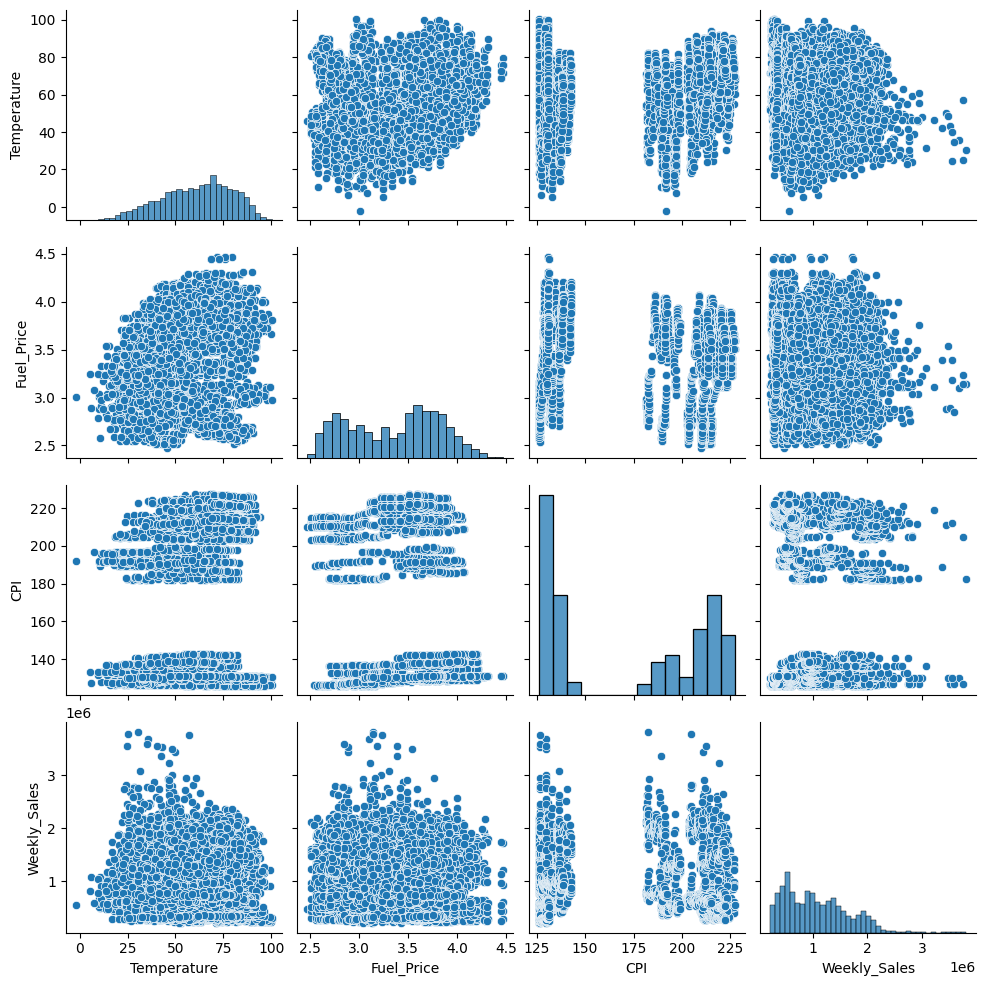

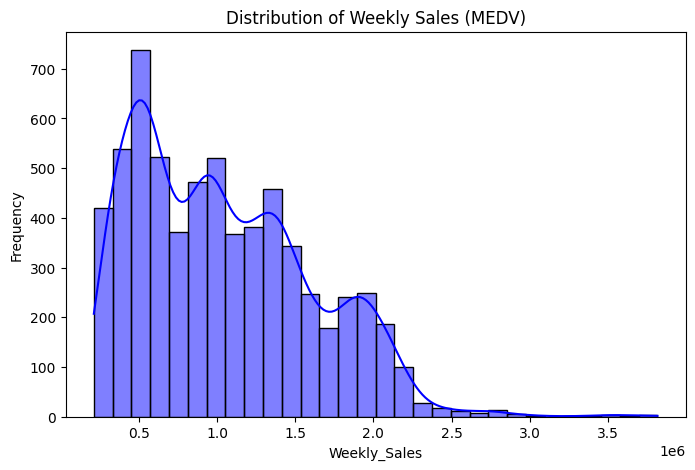

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Temperature', 'Fuel_Price', 'CPI', 'Weekly_Sales']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales ")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and Date
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1481
RMSE: 523884.7405


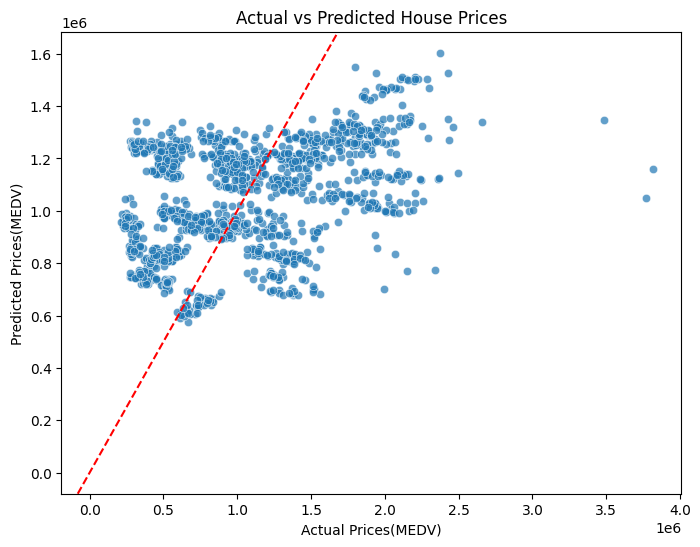

In [5]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

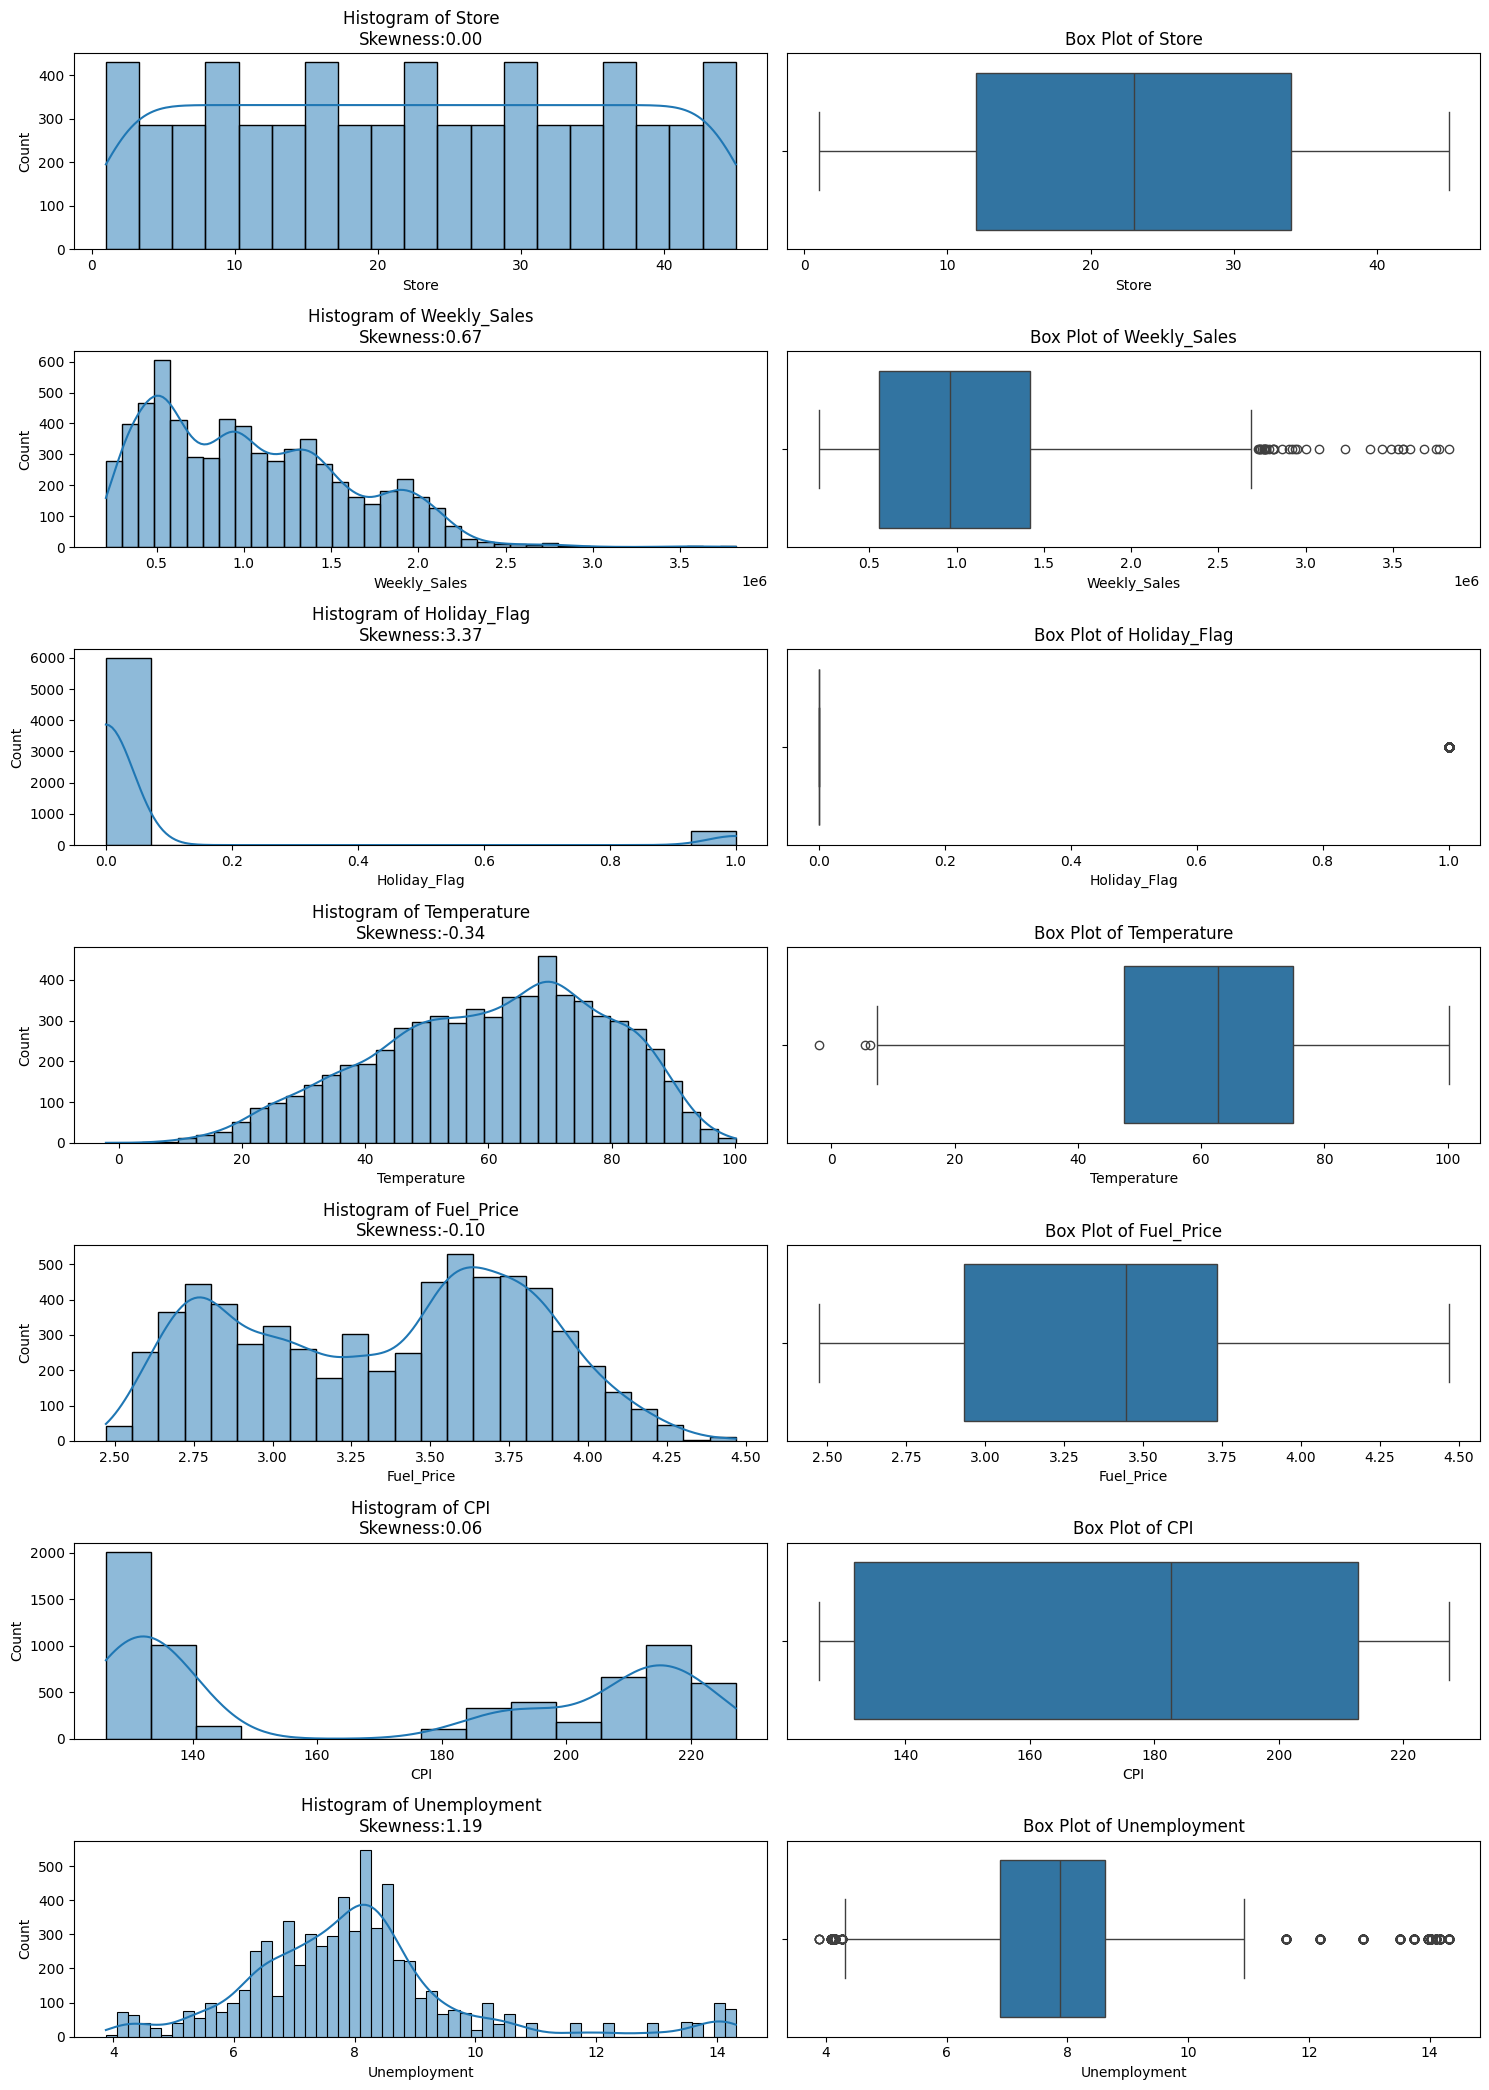

In [7]:
from scipy.stats import skew

# Select only numeric columns for skewness calculation and plotting
numeric_df = df.select_dtypes(include='number')
skewness = numeric_df.skew()

nums_cols = len(numeric_df.columns)
plt.figure(figsize=(15, nums_cols * 3))

for i, col in enumerate(numeric_df.columns):
  plt.subplot(nums_cols, 2, 2 * i + 1)
  sns.histplot(numeric_df[col], kde=True)
  plt.title(f'Histogram of {col}\nSkewness:{skewness[col]:.2f}')

  plt.subplot(nums_cols, 2, 2 * i + 2)
  sns.boxplot(x=numeric_df[col])
  plt.title(f'Box Plot of {col}')
  plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Select only numeric columns for skewness calculation
numeric_df = df.select_dtypes(include='number')
skewed_cols = numeric_df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index

print("Highly Skewed Columns:")
print(highly_skewed)
print("\nNegatively Skewed Columns:")
print(negatively_skewed)

Highly Skewed Columns:
Index(['Holiday_Flag', 'Unemployment'], dtype='object')

Negatively Skewed Columns:
Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [10]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [12]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])
numeric_df.skew()

,0
Store,0.000000
Weekly_Sales,0.668362
Holiday_Flag,3.373499
Temperature,-0.336768
Fuel_Price,-0.096158
CPI,0.063492
Unemployment,1.188144


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Select only numerical columns for X to avoid the ValueError
X = df.select_dtypes(include=['number']).drop(columns=["Weekly_Sales"])
y=df["Weekly_Sales"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1343
RMSE: 0.9419


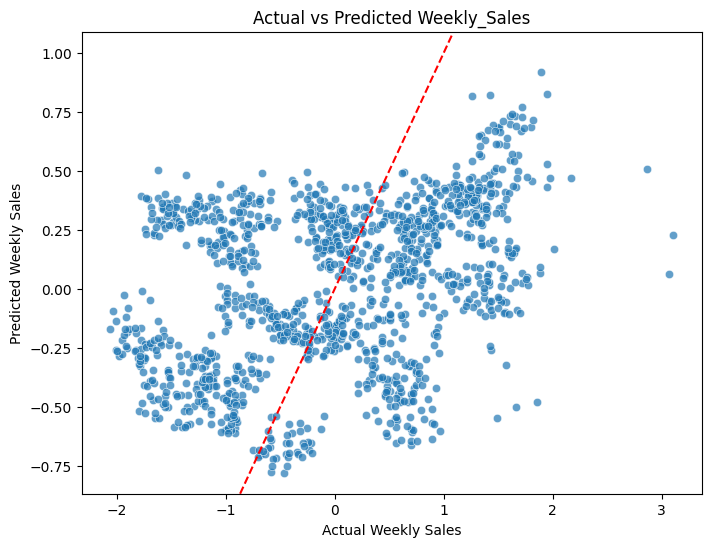

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.title("Actual vs Predicted Weekly_Sales")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
rmse_rf=mean_squared_error(y_test,y_pred)**0.5
r2=r2_score(y_test,y_pred)
print(f'Random Forest R² Score: {r2:.4f}')
print(f'Random Forest RMSE: {rmse_rf:.4f}')

Random Forest R² Score: 0.9604
Random Forest RMSE: 0.2014
